In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [67]:
df_titanic = sns.load_dataset('titanic').copy()
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [68]:
# Смотрим краткую информацию о данных
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [69]:
# Смотрим кол-во пропусков
df_titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Text(0.5, 1.0, 'Карта пропусков в данных')

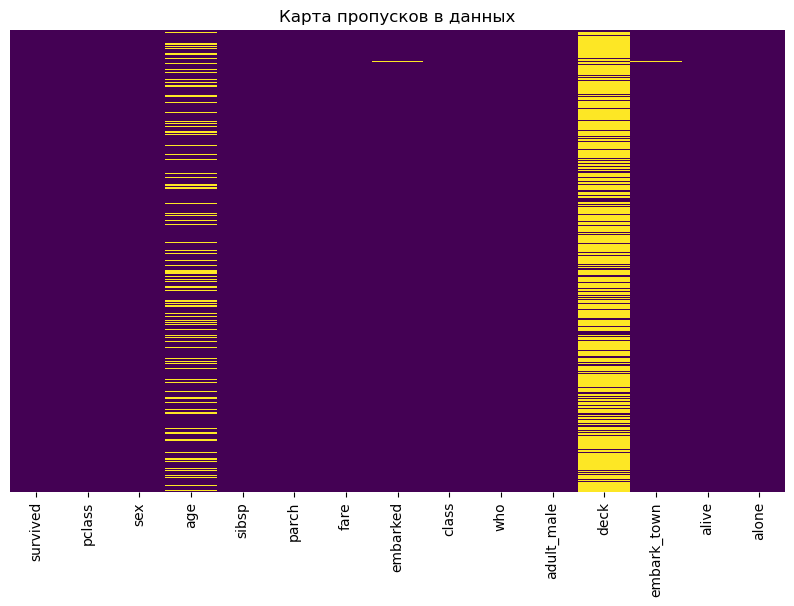

In [70]:
# Heatmap пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(df_titanic.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Карта пропусков в данных')

Text(0.5, 1.0, 'Полная корреляция признаков')

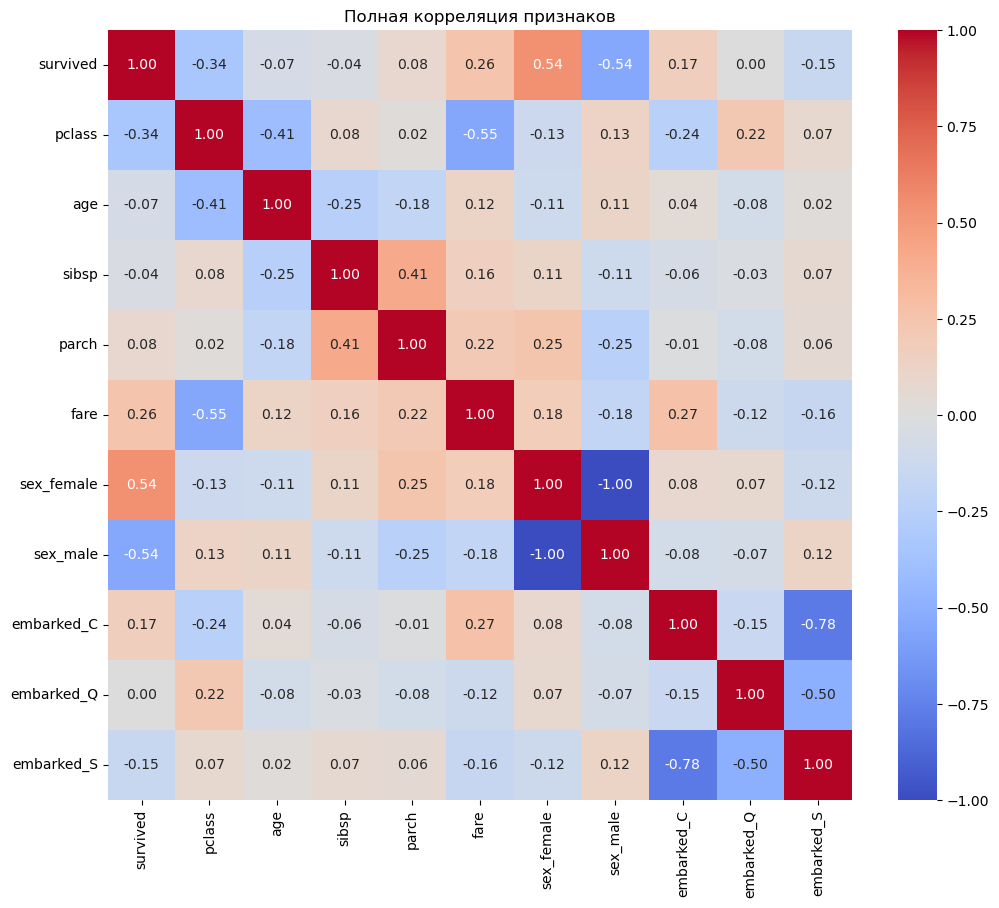

In [133]:
# Смотрим корреляцию всех признаков на тепловой карте, превратив колонки с категориями в бинарные
full_corr = pd.get_dummies(df_titanic).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Полная корреляция признаков')

Text(0.5, 1.0, 'Выжившие в разрезе пола')

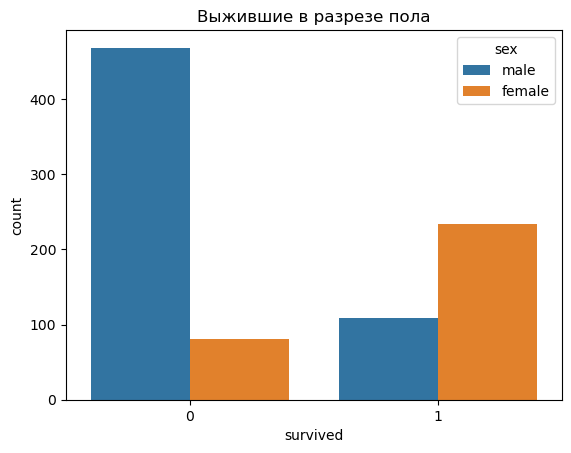

In [71]:
# График Countplot - самый главный для классификации
sns.countplot(x='survived', hue='sex', data=df_titanic)
plt.title('Выжившие в разрезе пола')

Text(0.5, 1.0, 'Выжившие в разрезе класса каюты')

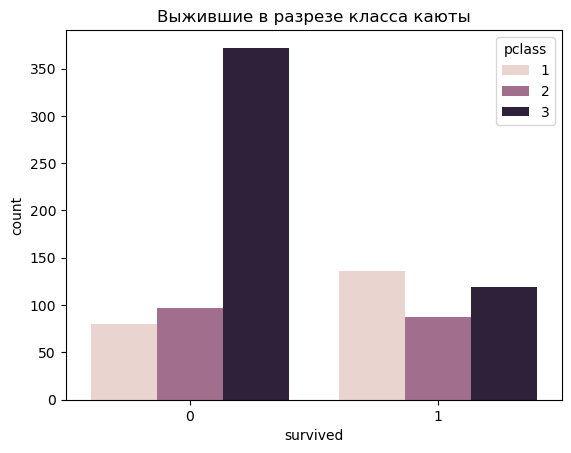

In [72]:
sns.countplot(x='survived', hue='pclass', data=df_titanic)
plt.title('Выжившие в разрезе класса каюты')

In [73]:
# Заполняем важную колонку с возрастом средним значением, сгруппировав по классу билета и полу
df_titanic['age'] = df_titanic['age'].fillna(df_titanic.groupby(['pclass', 'sex'])['age'].transform('mean'))
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.00,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.00,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,21.75,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.00,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [74]:
# Заполняем пропуски в колонке embarked наиболее частым значением (модой)
df_embarked_mode = df_titanic['embarked'].mode()[0]
df_titanic['embarked'] = df_titanic['embarked'].fillna(df_embarked_mode)

In [75]:
# Удаляем лишние колонки, которые могут запутать модель
df_titanic = df_titanic.drop(['class', 'who', 'adult_male', 'embark_town', 'alive', 'deck', 'alone'], axis=1)

In [76]:
df_titanic.isna().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [116]:
# Выделяем целевую переменную y
y = df_titanic['survived']
X = df_titanic.drop('survived', axis=1)
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.00,1,0,7.2500,S
1,1,1,female,38.00,1,0,71.2833,C
2,1,3,female,26.00,0,0,7.9250,S
3,1,1,female,35.00,1,0,53.1000,S
4,0,3,male,35.00,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.00,0,0,13.0000,S
887,1,1,female,19.00,0,0,30.0000,S
888,0,3,female,21.75,1,2,23.4500,S
889,1,1,male,26.00,0,0,30.0000,C


In [117]:
# Train_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [118]:
# Создаем и обучаем модель
from catboost import CatBoostClassifier
cat_cols = ['sex', 'embarked']
cat_model = CatBoostClassifier(iterations=1, 
                                  learning_rate=0.05, 
                                  depth=6, 
                                  cat_features=cat_cols, # ПЕРЕДАЕМ СПИСОК КАТЕГОРИЙ
                                  verbose=100, 
                                  random_seed=42)

cat_model.fit(X_train, y_train)

0:	learn: 0.6755560	total: 36.1ms	remaining: 0us


CatBoostClassifier(cat_features=['sex', 'embarked'], depth=6, iterations=1, learning_rate=0.05, random_seed=42, verbose=100)

In [134]:
# Проверка точности - сравниваем предсказания модели с реальными ответами y_test.
preds = cat_model.predict(X_test)
accuracy = accuracy_score(y_test, preds)
print(f"Точность модели: {accuracy * 100:.2f}%")

Точность модели: 82.12%


Text(0.5, 0, 'Важность признаков в %')

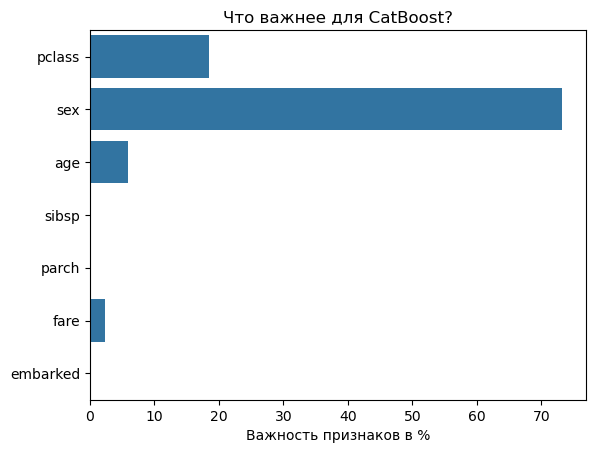

In [135]:
# Получаем важность признаков
importances = cat_model.get_feature_importance()
feature_names = cat_model.feature_names_
sns.barplot(x=importances, y=feature_names)
plt.title("Что важнее для CatBoost?")
plt.xlabel("Важность признаков в %")

In [138]:
pwd

'C:\\Users\\Sergey\\jupiter_projects\\ml_learning_titanic'